# MPA-MLF, Lab 6 - Feedforward Neural Networks with regularization techniques and hyperparameter tunning

## Exercise 1 - Classification of an images

The goal of this task will be to create Multi-layer perceptron model, that is able to recognize the  CIFAR10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html). The CIFAR10 dataset consist of 60000 images with resolution of 32x32 pixels. There are 10 classes in total - *airplane*, *automobile*, *bird*, *cat*, *deer*, *dog*, *frog*, *horse*, *ship*, *truck*

These is an example of the dataset:

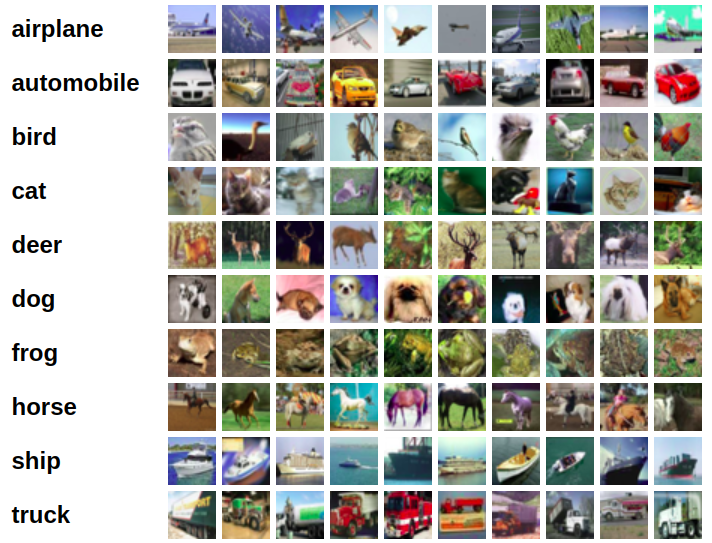

### 0. Import libraries

In [32]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import SGD
from keras.datasets import cifar10
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import cv2

font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

### 1. Load the Dataset
The dataset is already a part of the Keras library, so we can quickly load it using the following command

In [33]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

The following numbered labels represent the labels in the dataset:

In [34]:
labels = {0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

### 2. Data Examination

Fistly, lets have a look and the couple of images we have,

In [35]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels_encoded = y_data[selected_ind]
  selected_labels = [labels[x[0]] for x in selected_labels_encoded]

  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img)

  for id_label, label in enumerate(selected_labels):
    plt.text((32/2) + 32*id_label - len(label), 32*(5/4), label)
  plt.axis('off')
  plt.show()



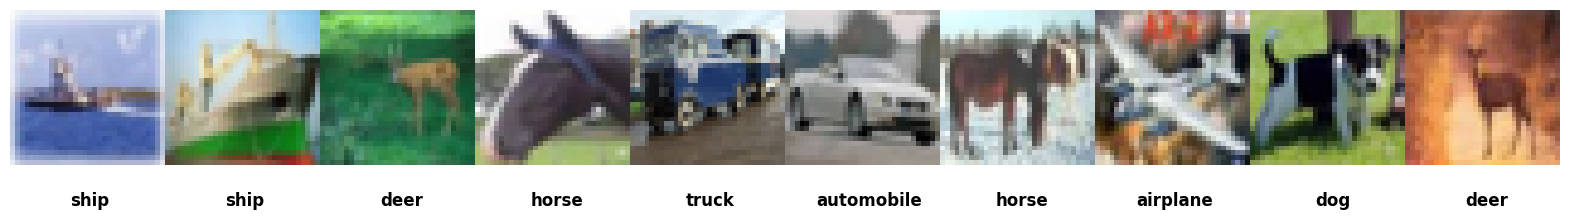

In [36]:
display_random_images(X_train, y_train)

In [37]:
#check the shape of image dataset

X_train.shape

(50000, 32, 32, 3)

In our dataset, we have 60000 images with 32x32 resolution. Each image has three channels (R, G, B). We have 50000 images for training and 10000 images for testing. Each channel for each image has values from 0 - 255, where each number represents the pixel intensity.
With the combination of intensities of R, G and B, you can display up to 16,777,216 different colours (256^3)

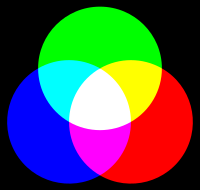

Here you can display each channel separately:

In [38]:
def display_channels_separately(image: np.array) -> None:

  plt.figure()
  fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(10, 5))


  axs[0].imshow(image[:,:,0],cmap='Reds')
  axs[1].imshow(image[:,:,1],cmap='Blues')
  axs[2].imshow(image[:,:,2],cmap='Greens')

  axs[3].imshow(image)

  plt.show()

<Figure size 640x480 with 0 Axes>

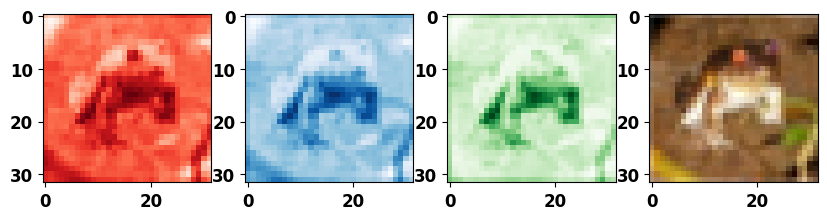

In [39]:
display_channels_separately(X_train[0])

### 3. Preprocessing of the images

For machine learning purposes, we have to preprocess our images. Firstly we need to scale our images, to scale intensity values from 0-1 (min-max scaling)

In [40]:
X_train_scaled = X_train.astype('float32') / 255.0

We need to one-hot-encode the labels in our ground truth variable as our second preprocessing.

In [41]:
y_train_encoded = to_categorical(y_train, num_classes=10)

### 4. Define the model architecture

**Description of modifications:**

To achieve a higher testing accuracy, I implemented several key modifications to the original Multi-Layer Perceptron (MLP) architecture and its training process:

1. **Activation Function:** I replaced the `sigmoid` activation function with `relu` in the hidden layers. This helps mitigate the vanishing gradient problem and allows the network to learn much faster and more effectively.
2. **Model Capacity:** The original model was too simple (only one layer with 128 neurons) for complex CIFAR-10 images. I increased the first hidden layer to 512 neurons and added a second hidden layer with 256 neurons to capture more complex patterns.
3. **Regularization:** To prevent the model from just memorizing the training data (overfitting), I introduced `Dropout` layers with a rate of 0.2 after each hidden layer.
4. **Optimizer:** I changed the optimizer from standard `SGD` to `Adam` (with a learning rate of 0.001), as it dynamically adapts the learning rate during training and usually converges to a better solution faster.
5. **Early Stopping & Epochs:** I increased the number of epochs to 50 but implemented an `EarlyStopping` callback (monitoring `val_loss` with a patience of 5). This allows the model to train for as long as it needs to, but automatically stops and restores the best weights if it stops improving.

These combined changes significantly improved the model's ability to generalize, resulting in a much higher testing accuracy compared to the initial baseline.

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# We initialize a Sequential model to stack our layers one after the other
model = Sequential()

# We flatten the 32x32x3 images into a 1D array of 3072 pixels so the Dense layers can process them
model.add(Flatten(input_shape=(32, 32, 3)))

# First hidden layer with 512 neurons and ReLU activation for better and faster learning
model.add(Dense(512, activation='relu'))

# Dropout randomly drops 20% of the connections to prevent the model from overfitting the training data
model.add(Dropout(0.2))

# Second hidden layer with 256 neurons to help the model learn more complex patterns
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

# Output layer with 10 neurons (one for each class) and softmax activation to output probabilities
model.add(Dense(10, activation='softmax'))

# We use the Adam optimizer here, which usually converges faster than standard SGD
optimizer = Adam(learning_rate=0.001)

# Compiling the model with categorical crossentropy since we have a multi-class classification problem
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Let's print the summary to see our new architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Train the model

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

# We define early stopping to monitor the validation loss.
# If the validation loss doesn't improve for 5 consecutive epochs (patience=5), training stops.
# 'restore_best_weights=True' ensures we keep the best version of our model.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# We can now train for more epochs (e.g., 50) because early stopping will catch it if it finishes sooner
history = model.fit(
    X_train_scaled,
    y_train_encoded,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.2658 - loss: 2.0254 - val_accuracy: 0.3260 - val_loss: 1.8775
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.3291 - loss: 1.8475 - val_accuracy: 0.3629 - val_loss: 1.7653
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.3547 - loss: 1.7880 - val_accuracy: 0.3546 - val_loss: 1.7605
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.3675 - loss: 1.7494 - val_accuracy: 0.4092 - val_loss: 1.6769
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.3840 - loss: 1.7058 - val_accuracy: 0.4113 - val_loss: 1.6660
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.3919 - loss: 1.6887 - val_accuracy: 0.4120 - val_loss: 1.6558
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.3986 - loss: 1.6646 - val_accuracy: 0.4380 - val_loss: 1.6011
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.4024 - loss: 1.6596 - 

Our model will be trained in the same way as in our last pc_labs,

### 6. Model evaluation

In [44]:
X_test = X_test.astype('float32') / 255.0
y_test_encoded = to_categorical(y_test, num_classes=10)

In [45]:
# We evaluate the model's performance on the unseen test dataset
score = model.evaluate(X_test, y_test_encoded, verbose=0)

print('Test loss:', score[0])
print(f'Test accuracy: {score[1]*100:.2f} %')

Test loss: 1.4611707925796509
Test accuracy: 47.89 %


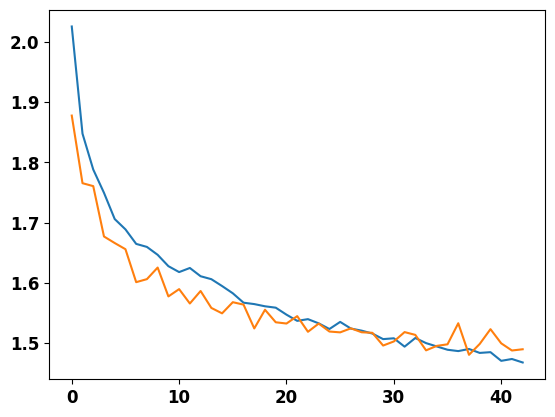

In [46]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

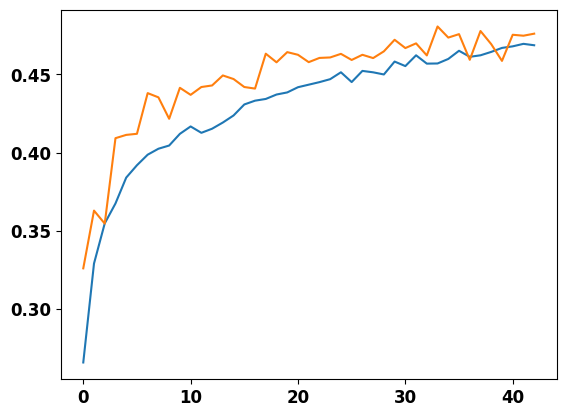

In [47]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

As you can see from the evaluation above, we was able to achive approx. 30% of an accuracy. In other word approx. 70% of an images we classified wrongly. That is really bad!

Lets check the best predictions from our model:

In [48]:
def show_the_best_predictions(model, x_test: np.array, y_test: np.array, n_of_pred: int = 10) -> None:
  mapping = {0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

  predictions = model.predict(x_test)
  y_test = y_test.reshape(1,-1)
  predictions_ind = np.argmax(predictions, axis=1)
  predictions_ind = predictions_ind.reshape(1, -1)

  corect_predictions = np.where(predictions_ind == y_test)

  rows_correct = corect_predictions[1]
  predictedtions_correct = predictions[rows_correct]
  target_correct = y_test[0][rows_correct]

  max_samples = predictions[rows_correct, target_correct]
  selected_images = x_test[rows_correct]
  sorted_ind = np.argsort(max_samples)[::-1]


  images = []
  prob = []
  labels = []


  for ind in range(n_of_pred):

    index = sorted_ind[ind]

    labels.append(target_correct[index])
    prob.append(max_samples[index])
    images.append(selected_images[index])

  plt.figure(figsize=(20,10))

  images = np.concatenate(np.asarray(images),axis=1)
  plt.imshow(images)
  for ins in range(n_of_pred):
    texts = '{}: \n{:.3f} %'.format(mapping[labels[ins]], prob[ins]*100)
    plt.text((32/2) + 32*ins - len(mapping[labels[ins]]), 32*(5/4), texts)

  plt.axis('off')
  plt.show()


### Task Description:

You task of this exercise would be to improve the model's performance to achieve better results in image classification task. There is no need to change the preprocessing of the dataset. There are possible way how to improve the models performance:

1. Hyperparameter tunning - change the hyperparameters so that the model will perform better. You can experiment with the following:
 - *changing the number of neurons in the hidden layer*
 - *changing the number of hidden layers*
 - *changing the activation functions*
 - *changing the learning rate*
 - *changing the optimizer* - So far, we have used only Gradient descend as our optimizer, but Keras offers other algorithms that can perform better - check the documentation!
 - *changing the number of learning epochs*\
 - *changing the batch size*

2. Regularization techniques - There are several regularization techniques that can improve the model's performance:
 - *Dropout* -  In the Keras lib. you can add *dropout layer* into your Sequential model using the following command  *model.add(Dropout(p))* where *p* is an hyperparameter that controls dropout probabily, typical values are 0.1 - 0.5.
 - *L1, L2 regularization* - In keras the regularization is applied for selected layers, there is an example how to add l2 regularization to an layer (for more details check the documnetation):  *model.add(Dense(64, activation='relu', input_dim=100, kernel_regularizer=l2(0.01)))*
 - *Early stopping* -  In Keras, you can use the EarlyStopping callback to implement early stopping in your model. *early_stopping = EarlyStopping(monitor='val_loss', patience=3)*,  *model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])*


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


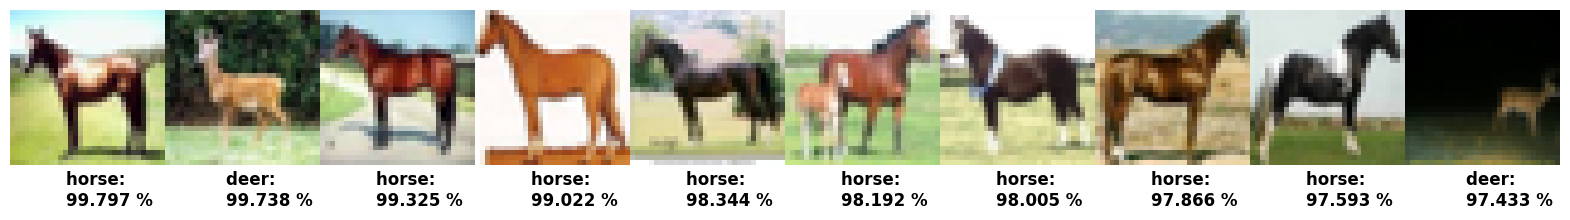

In [49]:
# We use the provided helper function to visualize the images our model was most confident about
# It is always good practice to visually inspect the results, not just look at the accuracy metric
show_the_best_predictions(model, X_test, y_test)

Try to make the highest testing accuracy possible. You can directly edit the code that is presented above, or you can copy everything into new cells. Please submit only the code with the best performance and briefly describe what approaches you have tried and what were the results

### Voluntary task:
Implement one of the hyperparameter tunning algorithms discussed in the lecture, such as *Grid Search*, *Random Search* or more sophisticated ones. Some of these algorithms are already included in the Keras. Check the documentation

In [50]:
# We install keras-tuner quietly (-q) so it doesn't clutter our notebook output
!pip install keras-tuner -q

In [51]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(hp):
    model = Sequential()

    # FIX: We use an explicit Input layer to define the shape clearly before flattening.
    # This prevents the "not fully defined" ValueError.
    model.add(Input(shape=(32, 32, 3)))
    model.add(Flatten())

    # The rest remains the same: Let the tuner choose the number of neurons
    hp_units = hp.Int('units', min_value=256, max_value=512, step=128)
    model.add(Dense(units=hp_units, activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(10, activation='softmax'))

    # Let the tuner choose the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [52]:
# We set up the Random Search tuner again, but this time we add overwrite=True.
# This forces the tuner to delete old, potentially corrupted trial logs and start totally fresh.
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='cifar10_tuning_dir',
    project_name='mlp_tuning',
    overwrite=True  # <--- This is the magic fix!
)

print("Starting the fresh hyperparameter search...")
tuner.search(X_train_scaled, y_train_encoded, epochs=10, validation_split=0.2)

Trial 1 Complete [00h 04m 23s]
val_accuracy: 0.4097000062465668

Best val_accuracy So Far: 0.4097000062465668
Total elapsed time: 00h 04m 23s

Search: Running Trial #2

Value             |Best Value So Far |Hyperparameter
512               |384               |units
0.001             |0.001             |learning_rate

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.2484 - loss: 2.0383 - val_accuracy: 0.3170 - val_loss: 1.8785
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.3188 - loss: 1.8739 - val_accuracy: 0.3567 - val_loss: 1.7897
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - accuracy: 0.3405 - loss: 1.8267 - val_accuracy: 0.3450 - val_loss: 1.8159
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.3495 - loss: 1.7909 - val_accuracy: 0.3729 - val_loss: 1.7525
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.3607 - loss: 1.7620 - val_accuracy: 0.3897 - val_loss: 1.7248
Epoch 6/10
1250/1250 

KeyboardInterrupt: 

In [ ]:
# Get the optimal hyperparameters found during the search
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The best number of neurons in the first layer is: {best_hps.get('units')}")
print(f"The best learning rate is: {best_hps.get('learning_rate')}")

# We can now build the final model with these optimal hyperparameters
best_model = tuner.hypermodel.build(best_hps)

